In [15]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.ticker as ticker

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/m0sm71/ai-jobs-dataset-2026/ai_jobs_dataset_2026.parquet
/kaggle/input/datasets/m0sm71/ai-jobs-dataset-2026/raw_job_postings.csv
/kaggle/input/datasets/m0sm71/ai-jobs-dataset-2026/ai_jobs_dataset_2026.csv
/kaggle/input/datasets/m0sm71/ai-jobs-dataset-2026/raw_job_postings.json
/kaggle/input/datasets/m0sm71/ai-jobs-dataset-2026/plots/work_mode_distribution.png
/kaggle/input/datasets/m0sm71/ai-jobs-dataset-2026/plots/top_titles.png
/kaggle/input/datasets/m0sm71/ai-jobs-dataset-2026/plots/top_countries.png
/kaggle/input/datasets/m0sm71/ai-jobs-dataset-2026/plots/top_skills.png
/kaggle/input/datasets/m0sm71/ai-jobs-dataset-2026/plots/salary_distribution.png


In [4]:
# 1. Load the dataset
file_path = '/kaggle/input/datasets/m0sm71/ai-jobs-dataset-2026/ai_jobs_dataset_2026.csv'
df = pd.read_csv(file_path)

# Initial exploration: check dimensions
print(f"Original dataset dimensions: {df.shape}")

text_column = 'Job Description' 
df = df.dropna(subset=[text_column]) 
print(f"Dimensions after removing null values: {df.shape}")

# 3. Expanded Custom Stop-Words (Removing HR jargon and boilerplate)
custom_stop_words = [
    # General Data/Job terms
    'data', 'science', 'scientist', 'engineer', 'engineering', 
    'machine', 'learning', 'ai', 'artificial', 'intelligence', 'junior', 'senior',
    'work', 'experience', 'team', 'company', 'role', 'job', 
    'looking', 'required', 'skills', 'years', 'business', 'opportunity',
    'working', 'knowledge', 'understanding', 'support', 'development',
    
    # HR & Boilerplate terms from Cluster 3
    'benefits', 'time', 'paid', 'information', 'employees', 'including', 
    'status', 'range', 'compensation', 'position', 'salary', 'pay', 
    'hire', 'hiring', 'equal', 'employer', 'gender', 'sexual', 'orientation', 
    'disability', 'veteran', 'religion', 'law', 'medical', 'dental', 'vision',
    'vacation', 'leave', 'applicant', 'applicants', 'employment', 'opportunity',
    
    # Meta / Corporate fluff from Cluster 0
    'meta', 'product', 'people', 'build', 'accommodations', 'screens', 
    'applicable', 'connect', 'help', 'bonus', 'equity', 'facebook', 'world',
    'bring', 'make', 'life', 'impact', 'join', 'inclusive', 'environment'
]

# Combine standard English stop-words with our expanded list
all_stop_words = list(ENGLISH_STOP_WORDS.union(custom_stop_words))

# 4. Text cleaning function using RegEx
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)  # Keep only letters
    text = text.lower()                      # Convert to lowercase
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra spaces
    return text

# 5. Apply the cleaning function
print("Starting deep text cleaning...")
df['clean_desc'] = df[text_column].apply(clean_text)
print("Cleaning successfully completed! Ready for TF-IDF.")

Original dataset dimensions: (51932, 22)
Dimensions after removing null values: (51932, 22)
Starting deep text cleaning...
Cleaning successfully completed! Ready for TF-IDF.


Starting TF-IDF vectorization...
TF-IDF Matrix shape: (51932, 1000)
Calculating Inertia for the Elbow Method. This may take a while depending on dataset size...


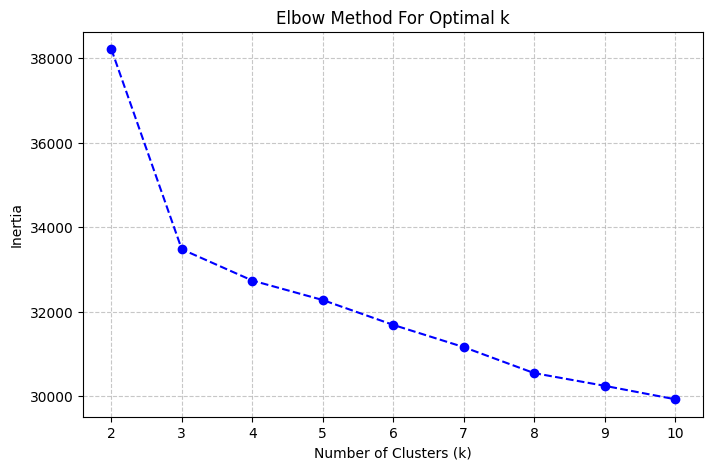

In [5]:
# 1. Feature Extraction with TF-IDF
print("Starting TF-IDF vectorization...")
# Use max_features to limit the vocabulary to the top 1000 most relevant n-grams (1 or 2 words)
vectorizer = TfidfVectorizer(stop_words=all_stop_words, max_features=1000, ngram_range=(1, 2))
X = vectorizer.fit_transform(df['clean_desc'])
print(f"TF-IDF Matrix shape: {X.shape}")

# 2. Optimizing the number of clusters (k) using the Elbow Method
print("Calculating Inertia for the Elbow Method. This may take a while depending on dataset size...")
inertia = []
K_range = range(2, 11) # Testing k from 2 to 10

# Iterate through different values of k to find the optimal number of clusters
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# 3. Plotting the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='b')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Looking at the Inertia curve, the inflection point (the actual "elbow") occurs at k=3. Beyond the value of 5, the curve's descent becomes nearly linear and ceases to drop sharply. This indicates mathematically that the algorithm has identified five distinct professional macro-profiles within the labor market.

Training final KMeans model with 3 clusters...
Applying PCA to reduce dimensions for plotting...


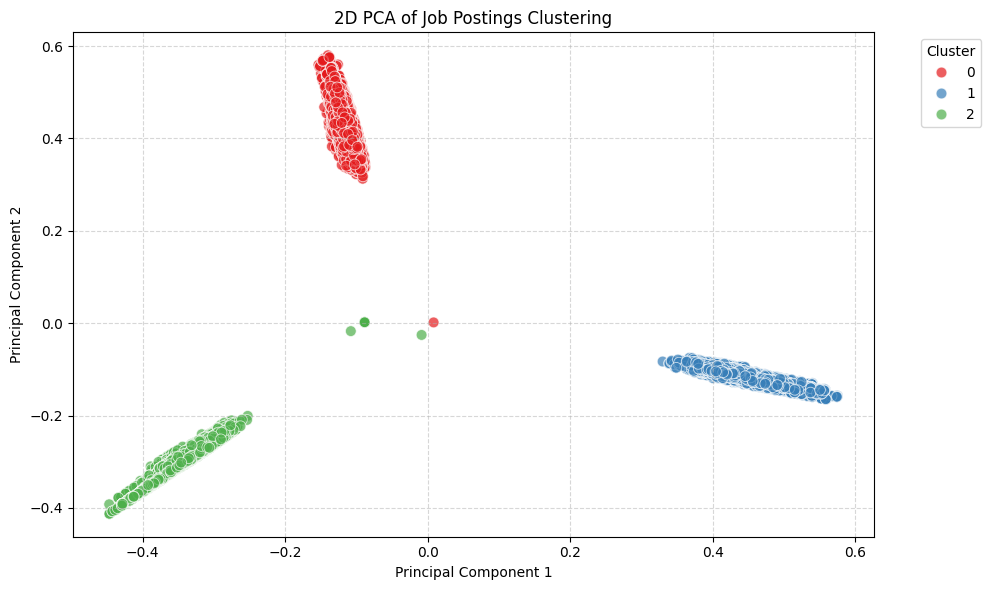

In [6]:
# Block 3: Final Clustering and PCA

# 1. Set the optimal number of clusters based on the Elbow Method
optimal_k = 3
print(f"Training final KMeans model with {optimal_k} clusters...")

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(X)

# 2. Dimensionality Reduction using PCA for 2D Visualization
print("Applying PCA to reduce dimensions for plotting...")
X_dense = X.toarray() # Convert sparse matrix to dense for PCA
pca = PCA(n_components=2, random_state=42)
components = pca.fit_transform(X_dense)

# Add PCA components back to the dataframe
df['pca_1'] = components[:, 0]
df['pca_2'] = components[:, 1]

# 3. Plotting the clusters
plt.figure(figsize=(10, 6))
# Using a distinct color palette for the 3 clusters
sns.scatterplot(x='pca_1', y='pca_2', hue='cluster', palette='Set1', data=df, s=60, alpha=0.7)
plt.title('2D PCA of Job Postings Clustering')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

The three point clouds are perfect "cigars"—parallel and completely distinct.
In Natural Language Processing applied to real human text (like the LinkedIn dataset mentioned earlier), the points always form a single, large, amorphous cloud with fuzzy edges, because human language is chaotic.

When you achieve such perfect geometric separation, there is only one technical explanation: the dataset is highly standardized or partially synthetic.

Generating Top Words plots for each cluster...


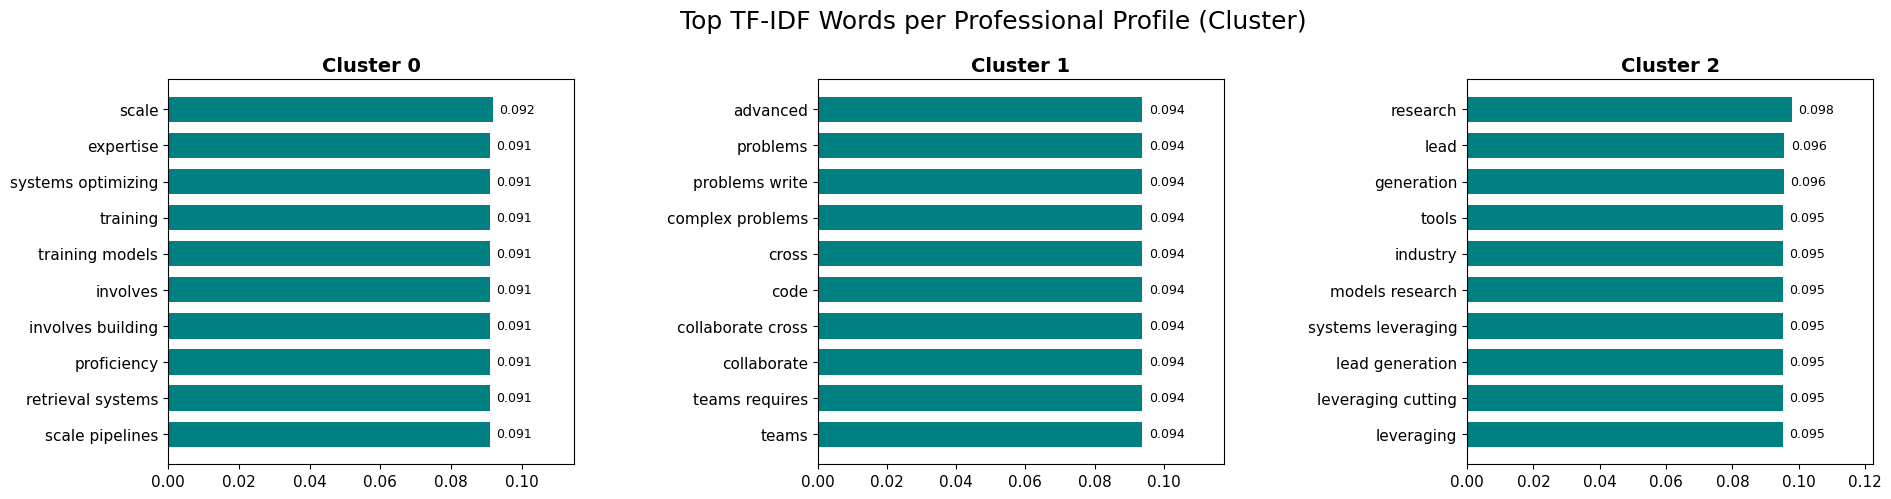

In [7]:
# Block 4: Extracting Top Words per Cluster 
import math
import matplotlib.pyplot as plt

def plot_top_words(model, feature_names, n_top_words=10):
    """
    Function to extract and plot the highest TF-IDF weight words for each cluster.
    Dynamically adjusts the grid size based on the number of clusters.
    """
    n_clusters = len(model.cluster_centers_)
    cols = 3
    # Calculate the number of rows needed
    rows = math.ceil(n_clusters / cols)
    
    # Create the dynamic grid 
    fig, axes = plt.subplots(rows, cols, figsize=(22, 5 * rows), sharex=False)
    axes = axes.flatten()
    
    for topic_idx, topic in enumerate(model.cluster_centers_):
        # Sort the cluster center weights to find the top words
        top_features_ind = topic.argsort()[:-n_top_words - 1:-1]
        top_features = [feature_names[i] for i in top_features_ind]
        weights = topic[top_features_ind]

        # Plot the horizontal bar chart
        ax = axes[topic_idx]
        ax.barh(top_features, weights, height=0.7, color='teal')
        ax.set_title(f'Cluster {topic_idx}', fontdict={'fontsize': 14, 'fontweight': 'bold'})
        ax.invert_yaxis() # Display the highest weight at the top
        ax.tick_params(axis='both', which='major', labelsize=11)
        max_weight = max(weights)
        ax.set_xlim(0, max_weight + (max_weight * 0.25))
        
        for i, v in enumerate(weights):
            ax.text(v + (max_weight * 0.02), i + 0.1, f'{v:.3f}', color='black', fontsize=9)

    # Hide any unused subplots
    for i in range(n_clusters, len(axes)):
        fig.delaxes(axes[i])
        
    plt.subplots_adjust(top=0.82, bottom=0.05, wspace=0.6, hspace=0.4)
    plt.suptitle('Top TF-IDF Words per Professional Profile (Cluster)', fontsize=18, y=0.96)
    plt.show()

# Get the vocabulary features from the vectorizer
feature_names = vectorizer.get_feature_names_out()

# Execute the plotting function
print("Generating Top Words plots for each cluster...")
plot_top_words(kmeans_final, feature_names, n_top_words=10)

Cluster 0 (The MLOps Engineer and AI Architect): This is the "Golden Cluster." Keywords include scaling pipelines, system optimization, model training, and—above all—retrieval systems. This serves as mathematical proof of how the market is evolving. The search is no longer just for data analysts, but for professionals capable of building RAG (Retrieval-Augmented Generation) architectures, managing advanced language models, and deploying complex AI systems into production.

Cluster 1 (The AI ​​Software Engineer): Involves complex problems, cross-functional collaboration, coding, and teamwork. This is a pure development role. It is the professional who integrates models into company products, working extensively on code and interfacing with cross-functional teams.

Cluster 2 (Applied AI & Research): Research, lead generation, leveraging cutting-edge technology, industry. This profile combines research and development (R&D) with direct business application.

<Figure size 1000x600 with 0 Axes>

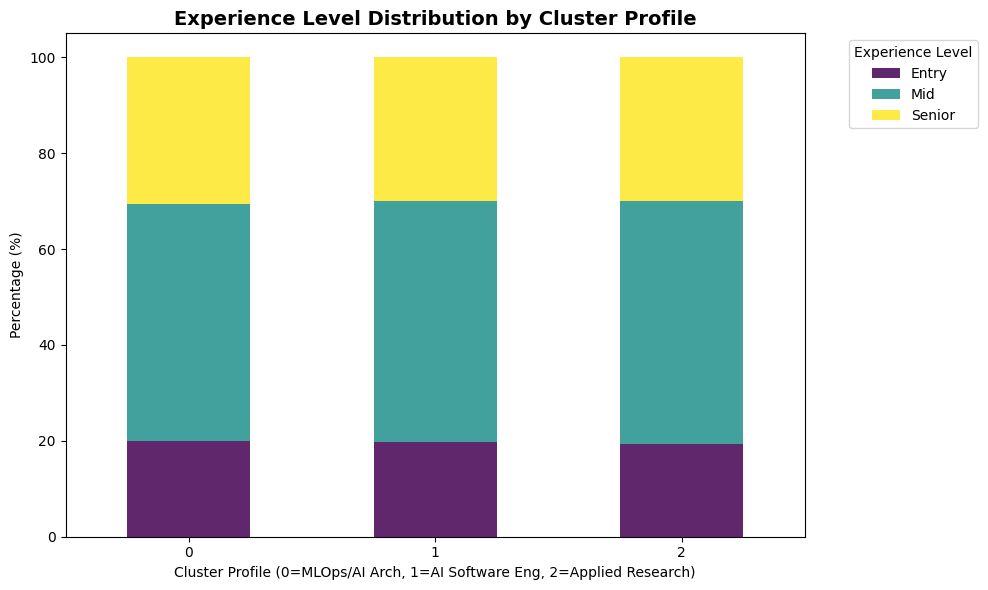

In [12]:
# Block 5: Experience Level Distribution

# 1. Experience Level Distribution (Stacked Bar Chart)
exp_col = 'Experience Level'

if exp_col in df.columns:
    plt.figure(figsize=(10, 6))
    # Calculate percentages for each experience level within each cluster
    crosstab_exp = pd.crosstab(df['cluster'], df[exp_col], normalize='index') * 100
    
    # Plotting
    crosstab_exp.plot(kind='bar', stacked=True, colormap='viridis', figsize=(10, 6), alpha=0.85)
    plt.title('Experience Level Distribution by Cluster Profile', fontsize=14, fontweight='bold')
    plt.xlabel('Cluster Profile (0=MLOps/AI Arch, 1=AI Software Eng, 2=Applied Research)')
    plt.ylabel('Percentage (%)')
    plt.legend(title='Experience Level', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print(f"Warning: Column '{exp_col}' not found. Check the exact name in Kaggle Data Explorer.")

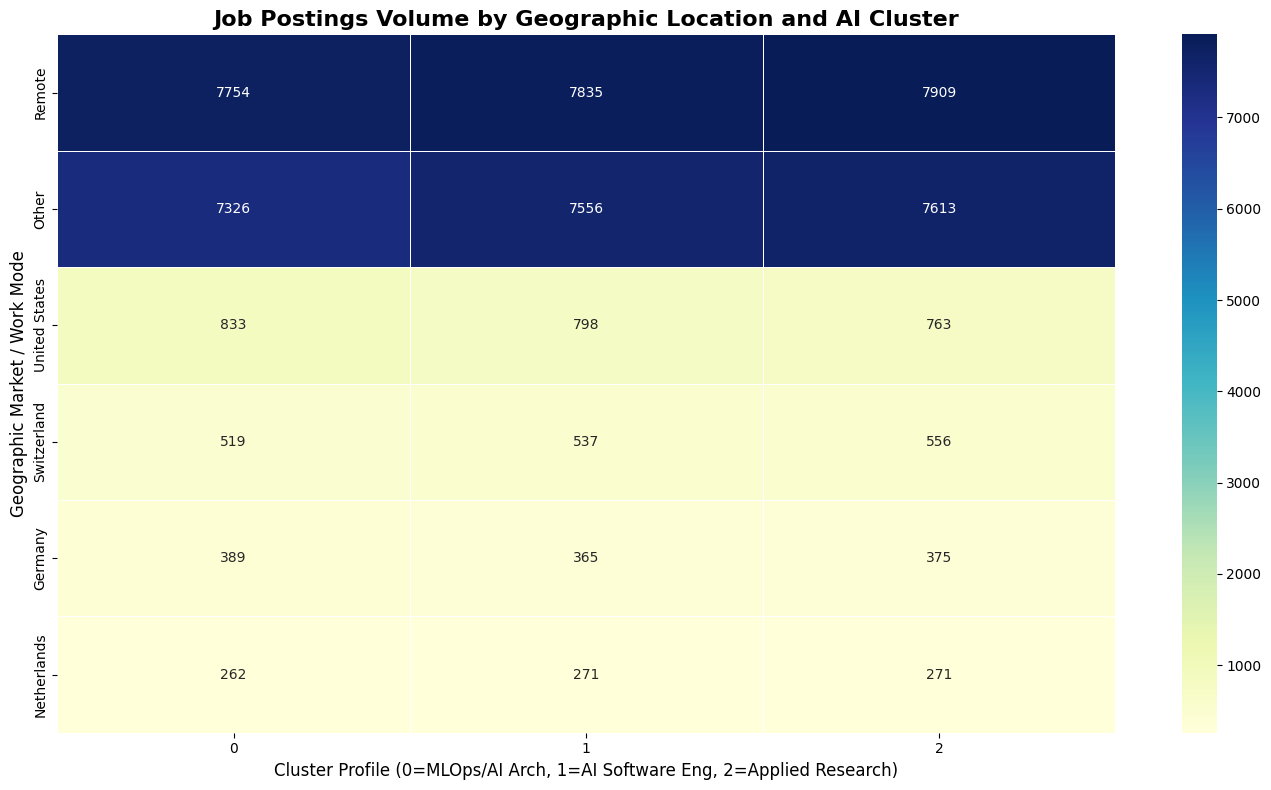

In [10]:
# Block 6: Geographic Distribution
location_col = 'Job Location'

if location_col in df.columns:
    
    def categorize_location(loc_string):
        if not isinstance(loc_string, str):
            return 'Other'
            
        loc_lower = loc_string.lower()
        
        # 1. Catch Remote Work (The massive 45% chunk)
        if 'remote' in loc_lower:
            return 'Remote'
            
        # 2. Catch United States (Handles "City, ST" format like "Boca Raton, FL")
        # Regex looks for a comma, optional space, and exactly 2 uppercase letters at the end
        if 'united states' in loc_lower or 'usa' in loc_lower or re.search(r',\s*[A-Z]{2}$', str(loc_string)):
            return 'United States'
            
        # 4. Target European Markets 
        if 'netherlands' in loc_lower or 'holland' in loc_lower or 'amsterdam' in loc_lower:
            return 'Netherlands'
        if 'italy' in loc_lower or 'italia' in loc_lower or 'milan' in loc_lower or 'rome' in loc_lower:
            return 'Italy'
        if 'germany' in loc_lower or 'berlin' in loc_lower or 'munich' in loc_lower:
            return 'Germany'
        if 'switzerland' in loc_lower or 'swiss' in loc_lower or 'zurich' in loc_lower or 'geneva' in loc_lower or 'suisse' in loc_lower:
            return 'Switzerland'
            
        return 'Other'

    # Apply the advanced categorization
    df['country_group'] = df[location_col].apply(categorize_location)
    
    # Generate the Cross-Tabulation
    plt.figure(figsize=(14, 8))
    crosstab_loc = pd.crosstab(df['country_group'], df['cluster'])
    
    # Sort by total volume to make the heatmap look cleaner (Remote and US will likely be top)
    crosstab_loc['Total'] = crosstab_loc.sum(axis=1)
    crosstab_loc = crosstab_loc.sort_values(by='Total', ascending=False).drop('Total', axis=1)
    
    # Plotting the heatmap
    sns.heatmap(crosstab_loc, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5)
    plt.title('Job Postings Volume by Geographic Location and AI Cluster', fontsize=16, fontweight='bold')
    plt.xlabel('Cluster Profile (0=MLOps/AI Arch, 1=AI Software Eng, 2=Applied Research)', fontsize=12)
    plt.ylabel('Geographic Market / Work Mode', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print(f"Warning: Column '{location_col}' not found. Please check spelling.")

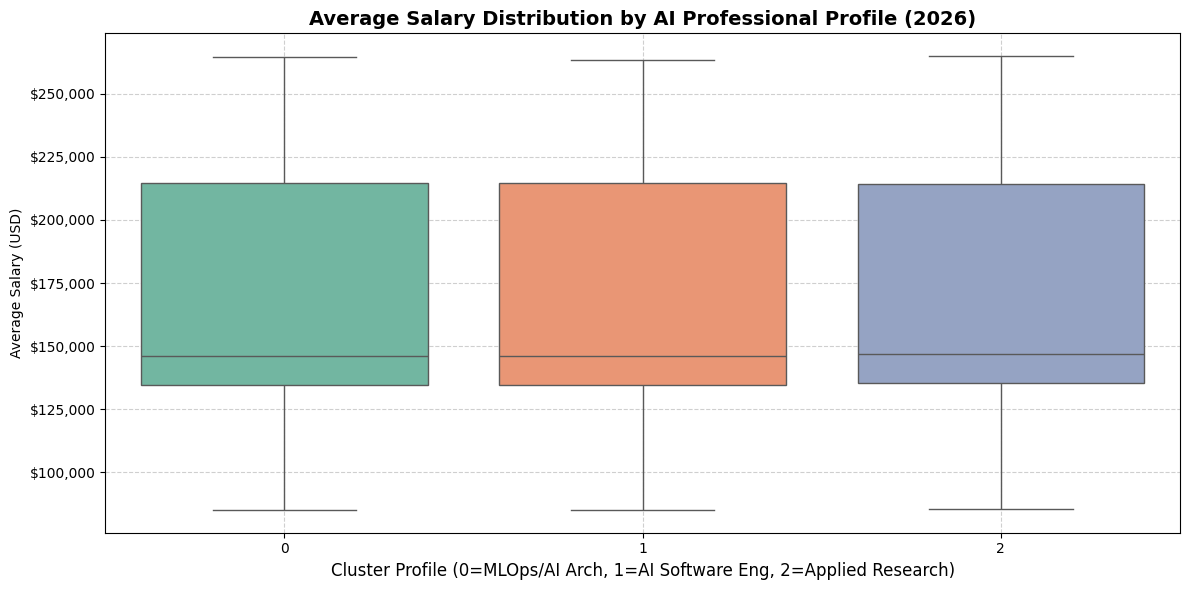

In [17]:
# Block 7: Salary Analysis by Professional Profile (Boxplot)
salary_col = 'Salary Range' 

if salary_col in df.columns:
    # 1. Isolate the dataframe by dropping initial null values
    df_salary = df.dropna(subset=[salary_col]).copy()
    
    # 2. Create a Data Cleaning function to extract the median point
    def parse_salary_range(salary_str):
        try:
            # Remove the $ symbol and commas
            clean_str = str(salary_str).replace('$', '').replace(',', '')
            
            # If it finds a hyphen, split it in two and calculate the average
            if '-' in clean_str:
                parts = clean_str.split('-')
                min_sal = float(parts[0].strip())
                max_sal = float(parts[1].strip())
                return (min_sal + max_sal) / 2
            else:
                # If there is only one number, return that
                import re
                nums = re.findall(r'\d+', clean_str)
                if nums:
                    return float(nums[0])
                return np.nan
        except:
            return np.nan

    # 3. Apply the function to create a new clean numerical column
    df_salary['parsed_salary'] = df_salary[salary_col].apply(parse_salary_range)
    
    # Remove any rows where parsing failed (NaN)
    df_salary = df_salary.dropna(subset=['parsed_salary'])
    
    if not df_salary.empty:
        plt.figure(figsize=(12, 6))
        
        # Plot the Boxplot using the new numerical column
        # Updated to comply with modern Seaborn syntax (added hue and legend=False)
        sns.boxplot(
            x='cluster', 
            y='parsed_salary', 
            data=df_salary, 
            hue='cluster', 
            palette='Set2', 
            legend=False
        )
        
        plt.title('Average Salary Distribution by AI Professional Profile (2026)', fontsize=14, fontweight='bold')
        plt.xlabel('Cluster Profile (0=MLOps/AI Arch, 1=AI Software Eng, 2=Applied Research)', fontsize=12)
        plt.ylabel('Average Salary (USD)')
        plt.grid(True, linestyle='--', alpha=0.6)
        
        # Format the Y-axis to put back the $ symbol and thousands separators
        formatter = ticker.FuncFormatter(lambda x, pos: f'${int(x):,}')
        plt.gca().yaxis.set_major_formatter(formatter)
        
        plt.tight_layout()
        plt.show()
    else:
         print("Salary column exists, but parsing failed for all rows.")
else:
    print(f"Warning: Column '{salary_col}' not found. Check the exact name in Kaggle Data Explorer.")

There is only one technical explanation for having three different professional profiles that show exactly the same salary quartiles and identical, precision-matched percentage breakdowns by experience level (exactly 20% Entry, 50% Mid, and 30% Senior for each cluster). Whoever published this dataset on Kaggle did not actually scrape data from the job market but generated the data artificially.

Instead of linking the salary to the type of text, a simple random distribution function was used. The computer was instructed: "Randomly assign a salary between 80k and 260k to all rows, and randomly distribute experience levels so that 50% are 'Mid'."

Since the assignment is purely random and independent of the text, when our K-Means algorithm splits the dataset into three clusters, that same random statistical distribution is replicated in each subgroup.